# SkeletonOrderDAGBuilder

## Overview

`SkeletonOrderDAGBuilder` builds a DAG by combining an **undirected skeleton** (PC algorithm) with a **causal order** (LiNGAM-type algorithm). This notebook applies it to a high-dimensional small-sample setting ($p > n$).

1. **PC** (`skeleton_`, `possible_ancestors_`): removes edges by conditional independence tests (Fisher's Z) to get the skeleton and the possible ancestors of each variable.
2. **PriorConstrainedHighDimLiNGAM** (`causal_order_`): high-dimensional DirectLiNGAM (Wang & Drton, 2020) with candidate parents restricted to already-ordered variables that are possible ancestors per PC.
3. **SkeletonOrderDAGBuilder** (`dag_`, `adjacency_matrix_`): orients each skeleton edge from the earlier to the later variable in the causal order (always acyclic); if `X` is given, coefficients are estimated by linear regression on the parents.



In [1]:
import subprocess

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from skelordag import PC, PriorConstrainedHighDimLiNGAM, SkeletonOrderDAGBuilder

## Generating High-Dimensional Small-Sample Data

The same analysis flow as in the existing `SkeletonOrderDAGBuilder` verification notebook is applied to a high-dimensional small-sample case with `p > n`.

- Number of variables: `n_features = 30`
- Number of samples: `n_samples = 15` (since `n_samples <= n_features`, the downstream `PriorConstrainedHighDimLiNGAM` uses its estimation path for n<=p)
- The parents of each variable are chosen at random, up to 3, from the variables preceding it in the causal order (index order), consistent with the maximum in-degree `J=3`
- Noise follows a non-Gaussian (uniform) distribution

Matrices use the `matrix[child, parent]` orientation.

In [2]:
rng = np.random.default_rng(0)

n_features = 30
n_samples = 15
max_parents = 3

labels = [f"X{i}" for i in range(n_features)]

true_dag = np.zeros((n_features, n_features), dtype=int)
weights = np.zeros((n_features, n_features))

for child in range(n_features):
    n_parents = rng.integers(0, min(child, max_parents) + 1)
    if n_parents == 0:
        continue
    parents = rng.choice(child, size=n_parents, replace=False)
    signs = rng.choice([-1.0, 1.0], size=n_parents)
    magnitudes = rng.uniform(0.5, 1.5, size=n_parents)

    true_dag[child, parents] = 1
    weights[child, parents] = signs * magnitudes

noise = rng.uniform(-1.0, 1.0, size=(n_samples, n_features)) * np.sqrt(3.0)
X = np.zeros((n_samples, n_features))

for child in range(n_features):
    parents = np.where(true_dag[child] != 0)[0]
    X[:, child] = noise[:, child]
    if len(parents) > 0:
        X[:, child] += X[:, parents] @ weights[child, parents]

X_df = pd.DataFrame(X, columns=labels)

print(f"Generated data shape: {X_df.shape} (n_samples <= n_features: {n_samples <= n_features})")
print(f"Number of true edges: {int(true_dag.sum())}")
display(X_df.head())

Generated data shape: (15, 30) (n_samples <= n_features: True)
Number of true edges: 38


,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X20,X21,X22,X23,X24,X25,X26,X27,X28,X29
0,-0.069324,-0.980452,1.045745,1.467152,-0.810149,0.134873,-0.198310,3.405415,-1.835571,0.803693,...,-1.594737,-0.992951,0.294811,3.373914,-0.835318,0.588339,1.859793,-0.997674,7.368288,2.264080
1,0.298339,0.417032,1.072870,0.209495,-0.732930,-0.301736,1.102003,2.037252,2.945376,-0.452396,...,-0.499119,-2.499319,0.102971,1.037391,-0.783410,0.713195,-0.733228,-1.323724,2.869317,-0.579121
2,-0.413023,-0.561209,-0.038626,1.650514,0.955022,-0.662138,-0.797309,2.244469,0.340472,0.037088,...,1.513171,-0.306813,0.432594,0.426603,0.743460,-2.129166,-0.158842,0.657160,-0.477564,-0.023829
3,-1.059566,-0.725496,0.081180,-1.423969,1.669498,0.247322,-1.709850,-3.224588,-0.445765,0.311319,...,-2.595823,-0.715667,-1.619982,4.442850,-1.428014,0.443149,0.129212,0.227109,0.069775,0.995675
4,1.438724,-0.183203,-1.477221,-1.488434,1.277749,0.464432,-0.011876,-3.083669,0.587227,-0.630406,...,-1.624940,3.491117,1.971948,-2.990258,1.086114,-0.024369,1.086889,2.867176,-5.327003,-2.846811


## Running the R Environment Check and the PC Algorithm

`PC` internally calls `pcalg::pc()` through `Rscript`. Because the small sample size lowers the power of the tests, the significance level `alpha` is set to a more lenient value (`0.05`) than in the existing verification notebook.

In [3]:
r_check = subprocess.run(
    [
        "Rscript",
        "-e",
        "library(pcalg); library(jsonlite); cat('R packages loaded successfully\\n')",
    ],
    capture_output=True,
    text=True,
)

if r_check.returncode != 0:
    raise RuntimeError(
        "R package check failed. PC.fit() requires Rscript plus the R packages "
        "pcalg and jsonlite. stderr:\n"
        f"{r_check.stderr}"
    )

print(r_check.stdout.strip())

R packages loaded successfully


In [4]:
pc = PC(alpha=0.05)
pc.fit(X_df)

skeleton = pc.skeleton_
possible_ancestors = pc.possible_ancestors_

skeleton_df = pd.DataFrame(skeleton, index=labels, columns=labels)
possible_ancestors_df = pd.DataFrame(possible_ancestors, index=labels, columns=labels)

expected_shape = (len(labels), len(labels))
assert skeleton.shape == expected_shape
assert possible_ancestors.shape == expected_shape
assert np.all(np.diag(skeleton) == 0)
assert np.array_equal(skeleton, skeleton.T)
assert possible_ancestors.dtype == bool

print("PC fit completed.")
# print(f"Estimated skeleton edges: {int(skeleton.sum()) // 2}")
# display(skeleton_df)
# print("Possible ancestors")
# display(possible_ancestors_df)

PC fit completed.


## Estimating the Causal Order with PriorConstrainedHighDimLiNGAM

The `possible_ancestors` obtained from PC are passed as constraints, and the causal order used to orient the skeleton is estimated. Since `n_samples <= n_features`, `fit()` does not use the adaptive lasso of the base class; it uses the constraint-aware estimation path for n<=p (`_estimate_adjacency_matrix2_with_constraints`).

In [5]:
lingam_model = PriorConstrainedHighDimLiNGAM(
    J=max_parents,
    K=4,
    alpha=0.5,
    possible_ancestors=possible_ancestors.T,
    random_state=42,
)
lingam_model.fit(X_df)

causal_order = lingam_model.causal_order_
adjacency_lingam = lingam_model.adjacency_matrix_

causal_order_df = pd.DataFrame(
    {
        "rank": range(len(causal_order)),
        "node": causal_order,
        "label": [labels[node] for node in causal_order],
    }
)
adjacency_lingam_df = pd.DataFrame(adjacency_lingam, index=labels, columns=labels)

print("PriorConstrainedHighDimLiNGAM fit completed.")
print(f"Estimated adjacency edges: {int(np.count_nonzero(adjacency_lingam))}")
# print("Estimated causal order")
# display(causal_order_df)
# print("Estimated adjacency matrix: matrix[child, parent] = coefficient")
# display(adjacency_lingam_df)

PriorConstrainedHighDimLiNGAM fit completed.
Estimated adjacency edges: 10


## Building the DAG with SkeletonOrderDAGBuilder

Each undirected edge of the PC skeleton is oriented according to the causal order.

In [6]:
builder = SkeletonOrderDAGBuilder(
    skeleton=skeleton,
    causal_order=causal_order,
).build(X_df)

final_dag_df = pd.DataFrame(builder.dag_, index=labels, columns=labels)
final_am_df = pd.DataFrame(builder.adjacency_matrix_, index=labels, columns=labels)

# print("Final DAG constructed.")
# display(final_dag_df)

# print("Final adjacency matrix constructed.")
# display(final_am_df)

## Diagnostic Comparison with the True Structure

The directed edges of the true DAG and the final DAG are compared.

In [7]:
def directed_edges(matrix, node_labels):
    return {
        (node_labels[parent], node_labels[child])
        for child in range(matrix.shape[0])
        for parent in range(matrix.shape[1])
        if matrix[child, parent] != 0
    }


true_edges = directed_edges(true_dag, labels)
estimated_edges = directed_edges(builder.dag_, labels)
recovered_edges = true_edges & estimated_edges
extra_edges = estimated_edges - true_edges
missed_edges = true_edges - estimated_edges

precision = len(recovered_edges) / len(estimated_edges) if estimated_edges else 0.0
recall = len(recovered_edges) / len(true_edges) if true_edges else 0.0

print(f"True edges:      {sorted(true_edges)}")
print(f"Estimated edges: {sorted(estimated_edges)}")
print(f"Recovered edges: {sorted(recovered_edges)}")
print(f"Extra edges:     {sorted(extra_edges)}")
print(f"Missed edges:    {sorted(missed_edges)}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")

True edges:      [('X0', 'X1'), ('X0', 'X10'), ('X0', 'X29'), ('X1', 'X10'), ('X1', 'X14'), ('X1', 'X21'), ('X1', 'X22'), ('X1', 'X26'), ('X10', 'X26'), ('X11', 'X12'), ('X11', 'X22'), ('X11', 'X25'), ('X14', 'X16'), ('X14', 'X27'), ('X15', 'X21'), ('X16', 'X20'), ('X16', 'X23'), ('X17', 'X21'), ('X19', 'X28'), ('X20', 'X28'), ('X21', 'X23'), ('X24', 'X26'), ('X25', 'X29'), ('X3', 'X12'), ('X3', 'X15'), ('X3', 'X29'), ('X3', 'X7'), ('X5', 'X11'), ('X5', 'X12'), ('X5', 'X7'), ('X6', 'X13'), ('X6', 'X7'), ('X6', 'X8'), ('X7', 'X28'), ('X8', 'X10'), ('X8', 'X15'), ('X8', 'X22'), ('X9', 'X13')]
Estimated edges: [('X0', 'X10'), ('X14', 'X16'), ('X14', 'X27'), ('X16', 'X20'), ('X17', 'X23'), ('X2', 'X29'), ('X23', 'X28'), ('X25', 'X29'), ('X3', 'X12'), ('X3', 'X7'), ('X4', 'X6'), ('X5', 'X12'), ('X6', 'X8'), ('X8', 'X15')]
Recovered edges: [('X0', 'X10'), ('X14', 'X16'), ('X14', 'X27'), ('X16', 'X20'), ('X25', 'X29'), ('X3', 'X12'), ('X3', 'X7'), ('X5', 'X12'), ('X6', 'X8'), ('X8', 'X15')]
E

## Graph Visualization

The true DAG, the skeleton estimated by PC, and the final DAG oriented by the causal order are displayed with the same layout. Because there are many variables, `spring_layout` is used for the layout and edge weight labels are omitted.

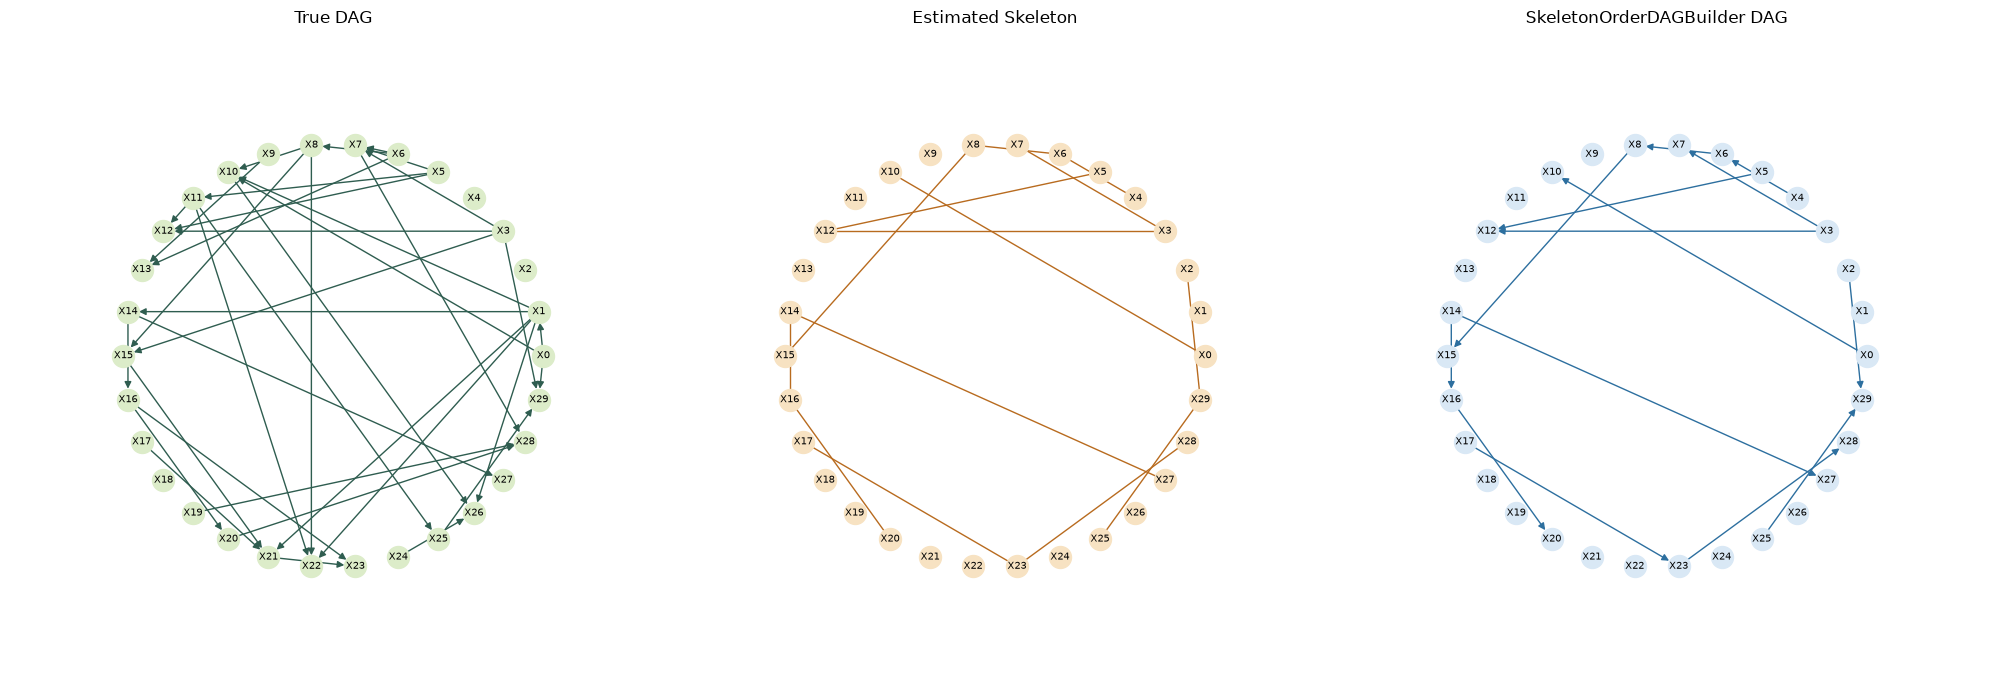

In [8]:
def graph_from_adjacency(matrix, node_labels, threshold=0.0):
    graph = nx.DiGraph()
    graph.add_nodes_from(node_labels)

    for child in range(matrix.shape[0]):
        for parent in range(matrix.shape[1]):
            coefficient = matrix[child, parent]
            if abs(coefficient) > threshold:
                graph.add_edge(
                    node_labels[parent],
                    node_labels[child],
                    weight=float(coefficient),
                )

    return graph


true_graph = graph_from_adjacency(weights, labels)
final_graph = graph_from_adjacency(builder.adjacency_matrix_, labels, threshold=1e-8)
skeleton_graph = nx.Graph()
skeleton_graph.add_nodes_from(labels)
for i in range(skeleton.shape[0]):
    for j in range(i + 1, skeleton.shape[1]):
        if skeleton[i, j] != 0 or skeleton[j, i] != 0:
            skeleton_graph.add_edge(labels[i], labels[j])

position = nx.circular_layout(true_graph.to_undirected())
# position = nx.spring_layout(true_graph.to_undirected(), seed=42)
figure, axes = plt.subplots(1, 3, figsize=(20, 7))

nx.draw_networkx(
    true_graph,
    pos=position,
    ax=axes[0],
    node_color="#DCECC9",
    edge_color="#2F5D50",
    node_size=250,
    font_size=7,
    arrows=True,
    arrowsize=10,
)
axes[0].set_title("True DAG")

nx.draw_networkx(
    skeleton_graph,
    pos=position,
    ax=axes[1],
    node_color="#F7E2C2",
    edge_color="#B86B1F",
    node_size=250,
    font_size=7,
)
axes[1].set_title("Estimated Skeleton")

nx.draw_networkx(
    final_graph,
    pos=position,
    ax=axes[2],
    node_color="#D9E8F5",
    edge_color="#2D6F9F",
    node_size=250,
    font_size=7,
    arrows=True,
    arrowsize=10,
)
axes[2].set_title("SkeletonOrderDAGBuilder DAG")

for axis in axes:
    axis.margins(0.2)
    axis.axis("off")

plt.tight_layout()
plt.show()